# 03 Analysis of HOMER Output

## Initialize

In [157]:
# Initialize Environment
# Do I really need all these libraries?
# Who knows, but they are here now
library(ggplot2)
library(ggpubr)
library(ggsci)
library(ggprism)
library(dplyr)
library(tidyr)
library(viridis)

# Set working directory
setwd("/home/dalbao/AlbaoRunx3Manuscript/cutnrun")

In [158]:
# Shared plot theme used across this notebook (matches flow cytometry notebooks).
# Note: this shadows ggplot2::theme() in this session - use ggplot2::theme(...)
# for any further one-off tweaks in later cells, not theme(...).
theme <- theme_bw(base_size = 14, base_family = "sans") +
    ggplot2::theme(axis.text = element_text(size = 10),
                   axis.title = element_text(size = 12),
                   strip.text = element_text(size = 12),
                   legend.position = "none",
                   plot.title = element_text(size = 12),
                   panel.grid = element_blank())

In [159]:
# Read homer results for cluster 1 and cluster 2
cluster_1_homer <- read.csv("03_motif/cluster1.csv")
cluster_2_homer <- read.csv("03_motif/cluster2.csv")

In [160]:
# Make new column normalized enrichment (OddsRatio) for each motif in cluster 1 and cluster 2
# Which is (TargetPercent)/BackgroundPercent
cluster_1_homer <- cluster_1_homer %>%
    mutate(OddsRatio = TargetPercent / BackgroundPercent)

cluster_2_homer <- cluster_2_homer %>%
    mutate(OddsRatio = TargetPercent / BackgroundPercent)

head(cluster_1_homer)
head(cluster_2_homer)

,TF,FamilyName,Assay,Accession,Database,Consensus,PValue,QValue,TargetNumber,TargetPercent,BackgroundNumber,BackgroundPercent,OddsRatio
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,RUNX,Runt,HPC7-Runx1-ChIP-Seq,GSE22178,Homer,SAAACCACAG,1e-122,0,752,63.19,22444.1,29.96,2.109146
2,RUNX-AML,Runt,CD4+-PolII-ChIP-Seq,Barski_et_al.,Homer,GCTGTGGTTW,1e-87,0,680,57.14,22017.8,29.39,1.944199
3,RUNX2,Runt,PCa-RUNX2-ChIP-Seq,GSE33889,Homer,NWAACCACADNN,1e-76,0,722,60.67,25608.2,34.19,1.774495
4,RUNX1,Runt,Jurkat-RUNX1-ChIP-Seq,GSE29180,Homer,AAACCACARM,1e-73,0,804,67.56,31040.3,41.44,1.630309
5,Etv2,ETS,ES-ER71-ChIP-Seq,GSE59402,Homer,NNAYTTCCTGHN,1e-71,0,770,64.71,29167.9,38.94,1.661787
6,ETS1,ETS,Jurkat-ETS1-ChIP-Seq,GSE17954,Homer,ACAGGAAGTG,1e-67,0,824,69.24,33070.7,44.15,1.568290


,TF,FamilyName,Assay,Accession,Database,Consensus,PValue,QValue,TargetNumber,TargetPercent,BackgroundNumber,BackgroundPercent,OddsRatio
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,RUNX,Runt,HPC7-Runx1-ChIP-Seq,GSE22178,Homer,SAAACCACAG,1e-164,0,1620,54.33,22385.9,30.13,1.803186
2,RUNX-AML,Runt,CD4+-PolII-ChIP-Seq,Barski_et_al.,Homer,GCTGTGGTTW,1e-124,0,1494,50.10,21782.9,29.32,1.708731
3,ELF1,ETS,Jurkat-ELF1-ChIP-Seq,SRA014231,Homer,AVCCGGAAGT,1e-120,0,1400,46.95,19959.7,26.87,1.747302
4,ETS1,ETS,Jurkat-ETS1-ChIP-Seq,GSE17954,Homer,ACAGGAAGTG,1e-119,0,1934,64.86,32444.8,43.67,1.485230
5,Elk4,ETS,Hela-Elk4-ChIP-Seq,GSE31477,Homer,NRYTTCCGGY,1e-118,0,1469,49.26,21574.5,29.04,1.696281
6,GABPA,ETS,Jurkat-GABPa-ChIP-Seq,GSE17954,Homer,RACCGGAAGT,1e-114,0,1816,60.90,29818.2,40.14,1.517190


In [161]:
# Keep only QValue < 0.05
cluster_1_homer <- cluster_1_homer %>%
    filter(QValue < 0.05)
cluster_2_homer <- cluster_2_homer %>%
    filter(QValue < 0.05)

In [162]:
# View all entries with a ? in FamilyName
cluster_1_homer %>%
    filter(grepl("\\?", FamilyName))

TF,FamilyName,Assay,Accession,Database,Consensus,PValue,QValue,TargetNumber,TargetPercent,BackgroundNumber,BackgroundPercent,OddsRatio
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GFY,?,Promoter,,Homer,ACTACAATTCCC,1e-10,0.0000,80,6.72,2263.2,3.02,2.225166
BANP,?,ESC-Banp-ChIP-Seq,GSE155603,Homer,TCTCGCGAGANY,1e-07,0.0000,102,8.57,3578.5,4.78,1.792887
GFY-Staf,?:Zf,Promoter,,Homer,RACTACAATTCCCAGAAKGC,1e-06,0.0000,67,5.63,2090.1,2.79,2.017921
GFX,?,Promoter,,Homer,ATTCTCGCGAGA,1e-05,0.0000,24,2.02,506.6,0.68,2.970588
CHR,?,Hela-CellCycle-Expression,,Homer,SRGTTTCAAA,1e-03,0.0033,292,24.54,15468.9,20.65,1.188378


In [163]:
# View all entries with a ? in FamilyName
cluster_2_homer %>%
    filter(grepl("\\?", FamilyName))

TF,FamilyName,Assay,Accession,Database,Consensus,PValue,QValue,TargetNumber,TargetPercent,BackgroundNumber,BackgroundPercent,OddsRatio
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GFY-Staf,?:Zf,Promoter,,Homer,RACTACAATTCCCAGAAKGC,1e-21,0.0000,179,6.00,1998.6,2.69,2.230483
GFY,?,Promoter,,Homer,ACTACAATTCCC,1e-19,0.0000,185,6.20,2210.7,2.98,2.080537
BANP,?,ESC-Banp-ChIP-Seq,GSE155603,Homer,TCTCGCGAGANY,1e-07,0.0000,209,7.01,3583.9,4.82,1.454357
CHR,?,Hela-CellCycle-Expression,,Homer,SRGTTTCAAA,1e-04,0.0001,738,24.75,15996.5,21.53,1.149559
HuR,?,HEK293-HuR-CLIP-Seq,GSE87887,Homer,BTTTGGTTTG,1e-03,0.0011,2542,85.24,61581.0,82.89,1.028351
GFX,?,Promoter,,Homer,ATTCTCGCGAGA,1e-03,0.0012,36,1.21,473.1,0.64,1.890625
GEI-11,Myb?,cElegans-L4-GEI11-ChIP-Seq,modEncode,Homer,CCGACAYYTYACGGG,1e-02,0.0055,110,3.69,2042.0,2.75,1.341818


In [164]:
# Remove all entries with a ? or blank in FamilyName
# Remove all entries with Promoter in TF, FamilyName, or Assay
cluster_1_homer <- cluster_1_homer %>%
    filter(!grepl("\\?", FamilyName) & FamilyName != "" & !grepl("Promoter|promoter", paste(TF, FamilyName, Assay)))
cluster_2_homer <- cluster_2_homer %>%
    filter(!grepl("\\?", FamilyName) & FamilyName != "" & !grepl("Promoter|promoter", paste(TF, FamilyName, Assay)))

In [165]:
# See unique values of FamilyName in descending order
family_counts <- table(cluster_1_homer$FamilyName)
family_counts <- sort(family_counts, decreasing = TRUE)
family_counts


        bZIP     AP2EREBP           Zf          MYB          ETS         bHLH 
          47           42           24           23           20           19 
         NAC          E2F          HTH     Homeobox          IRF     Trihelix 
          11            8            7            6            6            6 
         RHD        T-box       LOBAS2         Runt         C2H2 Homeobox:POU 
           5            5            4            4            3            3 
    bZIP:IRF          C3H        CAMTA      ETS:IRF     Forkhead          ARF 
           2            2            2            2            2            1 
    bHLH:ETS          BLH      C2C2dof        E2FDP     ETS:Runt          GRF 
           1            1            1            1            1            1 
       mTERF   MYBrelated           NR          NRF          SBP         THAP 
           1            1            1            1            1            1 
        WRKY 
           1 

In [166]:
# See unique values of FamilyName in descending order
family_counts <- table(cluster_2_homer$FamilyName)
family_counts <- sort(family_counts, decreasing = TRUE)
family_counts


     AP2EREBP          bZIP            Zf          bHLH           MYB 
           64            51            31            24            24 
          ETS           NAC           HTH           E2F           IRF 
           20            15             8             7             7 
     Trihelix            NR           RHD          Stat         T-box 
            6             5             5             5             5 
         WRKY          C2H2           HMG      Homeobox        LOBAS2 
            5             4             4             4             4 
         Runt           CPP         E2FDP  Homeobox:POU          MADS 
            4             3             3             3             3 
   MYBrelated      bZIP:IRF           C3H         CAMTA       ETS:IRF 
            3             2             2             2             2 
          HLH       ABI3VP1      bHLH:ETS bHLH:Homeobox           BLH 
            2             1             1             1             1 
     

In [167]:
# Remove plant TFs
# If FamilyName is:
# "AP2EREBP",
# "WRKY",
# "NAC",
# "LOBAS2",
# "BLH",
# "C2C2dof",
# "FAR1",
# "GRF",
# "mTERF",
# "REMB3",
# "SBP",
# "SRS",
# "TCP",
# "MADS",
# "CAMTA",
# "CPP",
# "ABI3VP1",
# "BZR",
# "G2like",
# "RWPRK",
# "ARF",
# "BES1" or 
# Accession is "GSE60143"

cluster_1_homer <- cluster_1_homer %>%
    filter(!FamilyName %in% c("AP2EREBP", "WRKY", "NAC", "LOBAS2", "BLH", "C2C2dof", "FAR1", "GRF", "mTERF", "REMB3", "SBP", "SRS", "TCP", "MADS", "CAMTA", "CPP", "ABI3VP1", "BZR", "G2like", "RWPRK", "ARF", "BES1", "MYB") & Accession != "GSE60143")
cluster_2_homer <- cluster_2_homer %>%
    filter(!FamilyName %in% c("AP2EREBP", "WRKY", "NAC", "LOBAS2", "BLH", "C2C2dof", "FAR1", "GRF", "mTERF", "REMB3", "SBP", "SRS", "TCP", "MADS", "CAMTA", "CPP", "ABI3VP1", "BZR", "G2like", "RWPRK", "ARF", "BES1", "MYB") & Accession != "GSE60143")

In [168]:
# See unique values of FamilyName in descending order
family_counts <- table(cluster_1_homer$FamilyName)
family_counts <- sort(family_counts, decreasing = TRUE)
family_counts


        bZIP           Zf          ETS         bHLH          E2F          HTH 
          26           24           20           12            8            7 
    Homeobox          IRF          RHD        T-box         Runt Homeobox:POU 
           6            6            5            5            4            3 
    bZIP:IRF      ETS:IRF     Forkhead     bHLH:ETS     ETS:Runt           NR 
           2            2            2            1            1            1 
         NRF         THAP 
           1            1 

In [169]:
# See unique values of FamilyName in descending order
family_counts <- table(cluster_2_homer$FamilyName)
family_counts <- sort(family_counts, decreasing = TRUE)
family_counts


           Zf          bZIP           ETS          bHLH           HTH 
           31            29            20            16             8 
          E2F           IRF            NR           RHD          Stat 
            7             7             5             5             5 
        T-box           HMG      Homeobox          Runt  Homeobox:POU 
            5             4             4             4             3 
     bZIP:IRF       ETS:IRF           HLH      bHLH:ETS bHLH:Homeobox 
            2             2             2             1             1 
     bZIP:RHD      ETS:Runt      Forkhead           NRF          THAP 
            1             1             1             1             1 

In [170]:
head(cluster_1_homer)

,TF,FamilyName,Assay,Accession,Database,Consensus,PValue,QValue,TargetNumber,TargetPercent,BackgroundNumber,BackgroundPercent,OddsRatio
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,RUNX,Runt,HPC7-Runx1-ChIP-Seq,GSE22178,Homer,SAAACCACAG,1e-122,0,752,63.19,22444.1,29.96,2.109146
2,RUNX-AML,Runt,CD4+-PolII-ChIP-Seq,Barski_et_al.,Homer,GCTGTGGTTW,1e-87,0,680,57.14,22017.8,29.39,1.944199
3,RUNX2,Runt,PCa-RUNX2-ChIP-Seq,GSE33889,Homer,NWAACCACADNN,1e-76,0,722,60.67,25608.2,34.19,1.774495
4,RUNX1,Runt,Jurkat-RUNX1-ChIP-Seq,GSE29180,Homer,AAACCACARM,1e-73,0,804,67.56,31040.3,41.44,1.630309
5,Etv2,ETS,ES-ER71-ChIP-Seq,GSE59402,Homer,NNAYTTCCTGHN,1e-71,0,770,64.71,29167.9,38.94,1.661787
6,ETS1,ETS,Jurkat-ETS1-ChIP-Seq,GSE17954,Homer,ACAGGAAGTG,1e-67,0,824,69.24,33070.7,44.15,1.568290


In [171]:
id_cols <- c("TF", "FamilyName", "Assay", "Accession", "Database", "Consensus")

combined_homer <- full_join(
        cluster_1_homer,
        cluster_2_homer,
        by = id_cols,
        suffix = c("_cluster1", "_cluster2")
    ) %>%
    mutate(
        PValue_cluster1 = coalesce(PValue_cluster1, 1),
        PValue_cluster2 = coalesce(PValue_cluster2, 1),
        QValue_cluster1 = coalesce(QValue_cluster1, 1),
        QValue_cluster2 = coalesce(QValue_cluster2, 1),
        OddsRatio_cluster1 = coalesce(OddsRatio_cluster1, 0.5),
        OddsRatio_cluster2 = coalesce(OddsRatio_cluster2, 0.5),
        TargetPercent_cluster1 = coalesce(TargetPercent_cluster1, 0.5),
        TargetPercent_cluster2 = coalesce(TargetPercent_cluster2, 0.5)
    )

In [172]:
head(x = combined_homer)
write.csv(combined_homer, "03_motif/combined_homer_results.csv", row.names = FALSE)

,TF,FamilyName,Assay,Accession,Database,Consensus,PValue_cluster1,QValue_cluster1,TargetNumber_cluster1,TargetPercent_cluster1,BackgroundNumber_cluster1,BackgroundPercent_cluster1,OddsRatio_cluster1,PValue_cluster2,QValue_cluster2,TargetNumber_cluster2,TargetPercent_cluster2,BackgroundNumber_cluster2,BackgroundPercent_cluster2,OddsRatio_cluster2
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,RUNX,Runt,HPC7-Runx1-ChIP-Seq,GSE22178,Homer,SAAACCACAG,1e-122,0,752,63.19,22444.1,29.96,2.109146,1e-164,0,1620,54.33,22385.9,30.13,1.803186
2,RUNX-AML,Runt,CD4+-PolII-ChIP-Seq,Barski_et_al.,Homer,GCTGTGGTTW,1e-87,0,680,57.14,22017.8,29.39,1.944199,1e-124,0,1494,50.10,21782.9,29.32,1.708731
3,RUNX2,Runt,PCa-RUNX2-ChIP-Seq,GSE33889,Homer,NWAACCACADNN,1e-76,0,722,60.67,25608.2,34.19,1.774495,1e-106,0,1620,54.33,25729.2,34.63,1.568871
4,RUNX1,Runt,Jurkat-RUNX1-ChIP-Seq,GSE29180,Homer,AAACCACARM,1e-73,0,804,67.56,31040.3,41.44,1.630309,1e-111,0,1849,62.01,30868.6,41.55,1.492419
5,Etv2,ETS,ES-ER71-ChIP-Seq,GSE59402,Homer,NNAYTTCCTGHN,1e-71,0,770,64.71,29167.9,38.94,1.661787,1e-106,0,1759,58.99,29003.2,39.04,1.511014
6,ETS1,ETS,Jurkat-ETS1-ChIP-Seq,GSE17954,Homer,ACAGGAAGTG,1e-67,0,824,69.24,33070.7,44.15,1.568290,1e-119,0,1934,64.86,32444.8,43.67,1.485230


In [173]:
families <- unique(combined_homer$FamilyName)

# Make a palette
library(paletteer)
pal <- paletteer_d("ggsci::category20_d3")
pal <- as.character(pal)
pal <- pal[1:length(c(families, "Other"))]
names(pal) <- c(families, "Other")

In [185]:
library(ggrepel)
library(MASS)

label_tfs <- c("RUNX", "RUNX-AML", "RUNX1", "RUNX2", "ETS1", "ETS:RUNX",
               "Fli1", "KLF3", "Jun-AP1", "AP-1", "Tbx21", "Tbet",
               "STAT1", "STAT4", "STAT5", "Tcf7")

# rows to label
to_label <- combined_homer %>%
  filter(!is.na(TF) & TF %in% label_tfs) %>%
  mutate(x = as.numeric(OddsRatio_cluster2),
         y = as.numeric(OddsRatio_cluster1))

# compute kde on the full point cloud (not just labeled points) for density context
kde <- MASS::kde2d(x = combined_homer$OddsRatio_cluster2,
                    y = combined_homer$OddsRatio_cluster1,
                    n = 120)

ix <- findInterval(to_label$x, kde$x)
iy <- findInterval(to_label$y, kde$y)
ix <- pmin(pmax(ix, 1), length(kde$x))
iy <- pmin(pmax(iy, 1), length(kde$y))
dens_vals <- kde$z[cbind(ix, iy)]
to_label$density <- dens_vals

density_cutoff <- quantile(to_label$density, probs = 0.4, na.rm = TRUE)
to_label$high_density <- ifelse(is.na(to_label$density), FALSE, to_label$density > density_cutoff)

to_label_high <- to_label %>% filter(high_density)
to_label_low  <- to_label %>% filter(!high_density)

p <- ggplot(combined_homer, aes(x = OddsRatio_cluster2, y = OddsRatio_cluster1, color = FamilyName)) +
  scale_color_manual(values = pal) +
  geom_point(size = 3, alpha = 0.7) +
  # crowded points (high density): stronger repulsion, tighter segments
  geom_text_repel(
    data = to_label_high,
    aes(x = x, y = y, label = TF),
    size = 3,
    max.overlaps = Inf,
    box.padding = 0.6,
    point.padding = 0.3,
    force = 3,
    segment.size = 0.3,
    segment.color = "grey40",
    min.segment.length = 0
  ) +
  # sparse points (low density): lighter repulsion, since they have room already
  geom_text_repel(
    data = to_label_low,
    aes(x = x, y = y, label = TF),
    size = 3,
    max.overlaps = Inf,
    box.padding = 0.3,
    point.padding = 0.2,
    force = 1,
    segment.size = 0.3,
    segment.color = "grey40",
    min.segment.length = 0
  ) +
  labs(x = "Odds Ratio (Cluster 2)", y = "Odds Ratio (Cluster 1)", color = "Family Name") +
  theme +
  ggplot2::theme(legend.position = "right", legend.title = element_text(size = 10),
        legend.text = element_text(size = 8), aspect.ratio = 1)

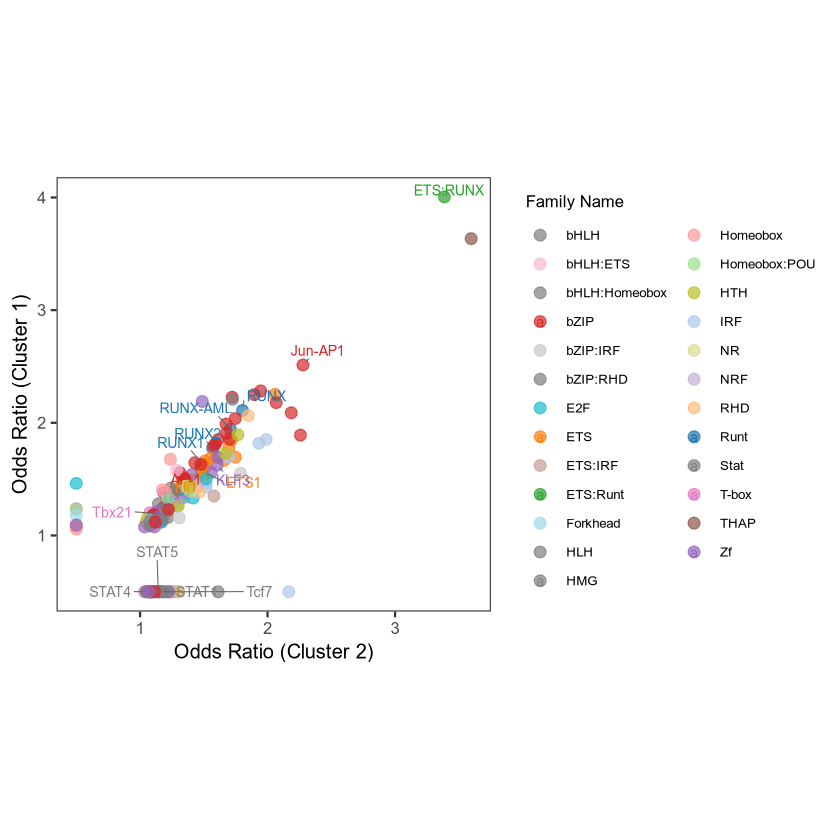

In [186]:
print(p)

In [187]:
pdf(file = "03_motif/or_plot.pdf", width = 8, height = 4)
print(p)
dev.off()

pdf 
  2

In [176]:
label_tfs <- c("RUNX", "RUNX-AML", "RUNX1", "RUNX2", "ETS1", "ETS:RUNX",
               "Fli1", "KLF3", "Jun-AP1", "AP-1", "Tbx21", "Tbet",
               "STAT1", "STAT4", "STAT5", "Tcf7")

# rows to label
to_label <- combined_homer %>%
  filter(!is.na(TF) & TF %in% label_tfs) %>%
  mutate(x = as.numeric(TargetPercent_cluster2),
         y = as.numeric(TargetPercent_cluster1))

# compute kde on the full point cloud (not just labeled points) for density context
kde <- MASS::kde2d(x = combined_homer$TargetPercent_cluster2,
                    y = combined_homer$TargetPercent_cluster1,
                    n = 120)

ix <- findInterval(to_label$x, kde$x)
iy <- findInterval(to_label$y, kde$y)
ix <- pmin(pmax(ix, 1), length(kde$x))
iy <- pmin(pmax(iy, 1), length(kde$y))
dens_vals <- kde$z[cbind(ix, iy)]
to_label$density <- dens_vals

density_cutoff <- quantile(to_label$density, probs = 0.4, na.rm = TRUE)
to_label$high_density <- ifelse(is.na(to_label$density), FALSE, to_label$density > density_cutoff)

to_label_high <- to_label %>% filter(high_density)
to_label_low  <- to_label %>% filter(!high_density)

p <- ggplot(combined_homer, aes(x = TargetPercent_cluster2, y = TargetPercent_cluster1, color = FamilyName)) +
  scale_color_manual(values = pal) +
  geom_point(size = 3, alpha = 0.7) +
  # crowded points (high density): stronger repulsion, tighter segments
  geom_text_repel(
    data = to_label_high,
    aes(x = x, y = y, label = TF),
    size = 3,
    max.overlaps = Inf,
    box.padding = 0.6,
    point.padding = 0.3,
    force = 3,
    segment.size = 0.3,
    segment.color = "grey40",
    min.segment.length = 0
  ) +
  # sparse points (low density): lighter repulsion, since they have room already
  geom_text_repel(
    data = to_label_low,
    aes(x = x, y = y, label = TF),
    size = 3,
    max.overlaps = Inf,
    box.padding = 0.3,
    point.padding = 0.2,
    force = 1,
    segment.size = 0.3,
    segment.color = "grey40",
    min.segment.length = 0
  ) +
  labs(x = "Target Percent (Cluster 2)", y = "Target Percent (Cluster 1)", color = "Family Name") +
  theme +
  ggplot2::theme(legend.position = "right", legend.title = element_text(size = 10),
        legend.text = element_text(size = 8), aspect.ratio = 1)

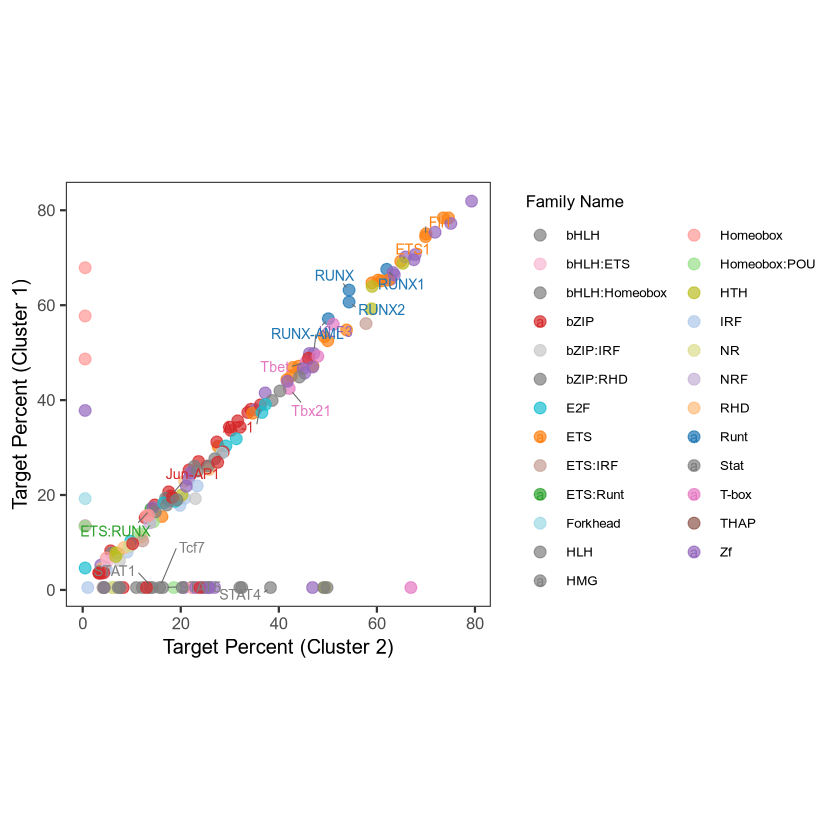

In [177]:
print(p)

## Background vs. target percent for Runt and ETS:Runt motifs

In [178]:
# Reshape to one row per TF x Cluster, with Background/Target percent as columns
# (dplyr::select is masked by MASS, loaded earlier for the KDE labeling code)
runt_ets_data <- combined_homer %>%
    filter(FamilyName %in% c("Runt", "ETS:Runt")) %>%
    dplyr::select(TF, FamilyName,
           BackgroundPercent_cluster1, TargetPercent_cluster1,
           BackgroundPercent_cluster2, TargetPercent_cluster2) %>%
    pivot_longer(
        cols = -c(TF, FamilyName),
        names_to = c(".value", "Cluster"),
        names_pattern = "(Background|Target)Percent_(cluster[12])"
    ) %>%
    mutate(Cluster = recode(Cluster, cluster1 = "Cluster 1", cluster2 = "Cluster 2"))

runt_ets_data

TF,FamilyName,Cluster,Background,Target
<chr>,<chr>,<chr>,<dbl>,<dbl>
RUNX,Runt,Cluster 1,29.96,63.19
RUNX,Runt,Cluster 2,30.13,54.33
RUNX-AML,Runt,Cluster 1,29.39,57.14
RUNX-AML,Runt,Cluster 2,29.32,50.10
RUNX2,Runt,Cluster 1,34.19,60.67
RUNX2,Runt,Cluster 2,34.63,54.33
RUNX1,Runt,Cluster 1,41.44,67.56
RUNX1,Runt,Cluster 2,41.55,62.01
ETS:RUNX,ETS:Runt,Cluster 1,4.26,17.06


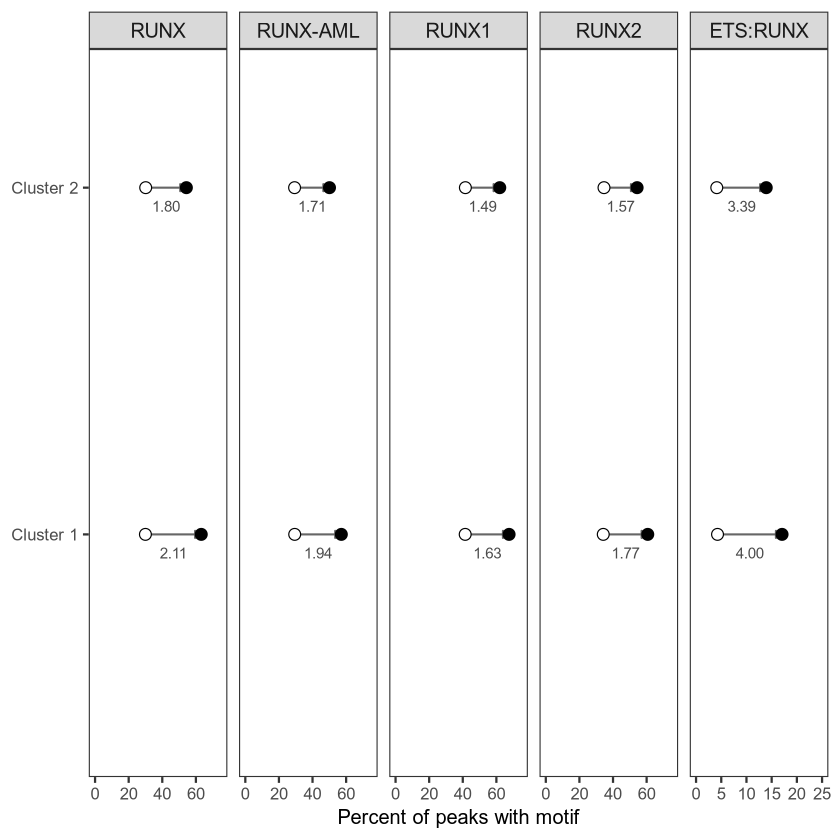

In [183]:
# Dumbbell plot: open circle = background %, filled circle = target %,
# odds ratio (target% / background%) labeled below the line,
# one row per cluster, one facet per motif (TF), Runt and ETS:Runt combined
tf_order <- runt_ets_data %>%
    distinct(TF, FamilyName) %>%
    mutate(FamilyName = factor(FamilyName, levels = c("Runt", "ETS:Runt"))) %>%
    arrange(FamilyName, TF) %>%
    pull(TF)
runt_ets_data <- runt_ets_data %>%
    mutate(TF = factor(TF, levels = tf_order),
           OddsRatio = Target / Background)

# Force each facet's x range: Runt motifs 0-100, ETS:Runt motif 0-50
x_range_limits <- runt_ets_data %>%
    distinct(TF, FamilyName) %>%
    mutate(xmax = ifelse(FamilyName == "Runt", 75, 25))
x_range_anchor <- bind_rows(
    x_range_limits %>% transmute(TF, x = 0),
    x_range_limits %>% transmute(TF, x = xmax)
) %>%
    mutate(Cluster = "Cluster 1")

p <- ggplot(runt_ets_data, aes(y = Cluster)) +
    geom_blank(data = x_range_anchor, aes(x = x, y = Cluster)) +
    geom_segment(aes(x = Background, xend = Target, yend = Cluster),
                 arrow = arrow(length = unit(0.15, "cm"), type = "closed"),
                 color = "grey40", linewidth = 0.6) +
    geom_point(aes(x = Background), shape = 21, fill = "white", color = "black", size = 3) +
    geom_point(aes(x = Target), shape = 21, fill = "black", color = "black", size = 3) +
    geom_text(aes(x = (Background + Target) / 2, label = sprintf("%.2f", OddsRatio)),
              vjust = 2.2, size = 3.2, color = "grey30") +
    facet_wrap(~ TF, nrow = 1, scales = "free_x") +
    labs(x = "Percent of peaks with motif", y = NULL) +
    scale_y_discrete(expand = expansion(add = c(0.7, 0.4))) +
    theme

print(p)

In [184]:
pdf("03_motif/dumbbell_plot_enrichment.pdf", width = 5, height = 2)
print(p)
dev.off()

pdf 
  2